<a href="https://colab.research.google.com/github/ldc902/battery-SOH-regression/blob/main/train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pickle
import re

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Activation
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_squared_log_error
from xgboost import plot_importance

# 1. Dataset

-discharge chứa Capacity => discharge là kết thúc của 1 cycle => số cycle = số Capacity = số discharge

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#. https://www.kaggle.com/datasets/patrickfleith/nasa-battery-dataset
ds = pd.read_csv('/content/drive/MyDrive/colab-notebooks/battery-SOH-regression/dataset/cleaned_dataset/metadata.csv')
ds

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7560,impedance,[2010. 9. 30. 7. 36. ...,24,B0055,247,7561,07561.csv,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.0201379996149256,NaN,NaN
7562,charge,[2010. 9. 30. 8. 48. 54.25],4,B0055,249,7563,07563.csv,NaN,NaN,NaN
7563,discharge,[2010. 9. 30. 11. 50. ...,4,B0055,250,7564,07564.csv,0.9907591663373165,NaN,NaN


In [ ]:
ds.shape  # 2D Dataframe: (rows, columns)

(7565, 10)

In [ ]:
ds = ds.drop(columns=["test_id", "uid", "filename"])
ds

,type,start_time,ambient_temperature,battery_id,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,1.5243662105099023,NaN,NaN
...,...,...,...,...,...,...,...
7560,impedance,[2010. 9. 30. 7. 36. ...,24,B0055,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,1.0201379996149256,NaN,NaN
7562,charge,[2010. 9. 30. 8. 48. 54.25],4,B0055,NaN,NaN,NaN
7563,discharge,[2010. 9. 30. 11. 50. ...,4,B0055,0.9907591663373165,NaN,NaN


# #. Data type

In [ ]:
for col in ds.columns:
    print(f"\n===== {col} =====")
    print(ds[col].map(type).unique())


===== type =====
[<class 'str'>]

===== start_time =====
[<class 'str'>]

===== ambient_temperature =====
[<class 'int'>]

===== battery_id =====
[<class 'str'>]

===== Capacity =====
[<class 'str'> <class 'float'>]

===== Re =====
[<class 'float'> <class 'str'>]

===== Rct =====
[<class 'float'> <class 'str'>]


In [ ]:
for col_name in ["type", "battery_id"]:
  if col_name == "battery_id":
    ds[col_name] = ds[col_name].apply(
      lambda val: str(val).strip() if pd.notnull(val) else val
    )
  else:
    ds[col_name] = ds[col_name].apply(
      lambda val: str(val).strip().lower() if pd.notnull(val) else val
    )

In [ ]:
def parse_start_time(s):

    if pd.isna(s):
        return pd.NaT

    s = s.strip("[]")

    nums = re.findall(r"[-+]?\d*\.?\d+(?:e[-+]?\d+)?", s)

    if len(nums) < 6:
        return pd.NaT

    year = int(float(nums[0]))
    month = int(float(nums[1]))
    day = int(float(nums[2]))
    hour = int(float(nums[3]))
    minute = int(float(nums[4]))

    second = float(nums[5])

    sec = int(second)
    micro = int(round((second-sec)*1_000_000))

    return pd.Timestamp(
        year,
        month,
        day,
        hour,
        minute,
        sec,
        micro
    )

ds["start_time"] = ds["start_time"].apply(parse_start_time)

In [ ]:
for col_name in ["ambient_temperature", "Capacity", "Re", "Rct"]:
  ds[col_name] = pd.to_numeric(ds[col_name], errors='coerce') # invalid thành NaN

# #. Missing by design
-c/m discharge chỉ chứa Capacity, impedance chỉ chứa Re và Rct, charge ko có Capacity, Re, Rct

In [ ]:
pd.crosstab(
    ds["type"],
    ds["Capacity"].isna()
)

Capacity,False,True
type,,
charge,0,2815
discharge,2769,25
impedance,0,1956


In [ ]:
pd.crosstab(
    ds["type"],
    ds["Re"].isna()
)

Re,False,True
type,,
charge,0,2815
discharge,0,2794
impedance,1947,9


In [ ]:
pd.crosstab(
    ds["type"],
    ds["Rct"].isna()
)

Rct,False,True
type,,
charge,0,2815
discharge,0,2794
impedance,1947,9


# #. Processing

In [ ]:
ds["start_time"].isna().sum()

np.int64(0)

In [ ]:
ds = ds.sort_values(
    ["battery_id", "start_time"]
).reset_index(drop=True)

In [ ]:
def count():
    x = 1

    def increase(value):
        nonlocal x

        if value == "discharge":
            x += 1
            return x - 1
        else:
            return x

    return increase

# thực hiện khai báo lambda trên mỗi nhóm, apply() gọi increase trên mỗi dòng
ds["cycle"] = ds.groupby("battery_id")["type"].transform(lambda g: g.apply(count()))


#=================================================
# cách 2
# is_discharge = ds["type"] == "discharge"
# ds["cycle"] = (
#     is_discharge.groupby(ds["battery_id"])
#     .shift(fill_value=False)
#     .groupby(ds["battery_id"])
#     .cumsum() + 1
# )

In [ ]:
ds.loc[ds["type"] == "discharge", "Capacity"].isna().sum()

np.int64(25)

In [ ]:
# xóa cycle mà discharge == NaN
discharge_bad_keys = ds.loc[
    (ds["type"] == "discharge") &
    (ds["Capacity"].isna()),
    ["battery_id", "cycle"]
]

ds = ds.merge(
    discharge_bad_keys,
    on=["battery_id", "cycle"],
    how="left",
    indicator=True
)

ds = (
    ds.loc[ds["_merge"] == "left_only"]
      .drop(columns="_merge")
      .reset_index(drop=True)
)

In [ ]:
# xóa cycle mà ko có dòng discharge
keys_of_rows = ds.groupby(["battery_id", "cycle"])["type"].apply(lambda x: "discharge" not in x.values)

cycle_bad_keys = keys_of_rows[keys_of_rows].index # chỉ giữ lại index True

ds = ds[~ds.set_index(["battery_id", "cycle"]).index.isin(cycle_bad_keys)].reset_index(drop=True) # chỉ giữ lại dòng True

In [ ]:
ds["ambient_temperature"].isna().sum()

np.int64(0)

In [ ]:
ds["ambient_temperature"].unique().tolist()

[24, 43, 44, 4, 22]

In [ ]:
ds[["temp_charge", "temp_discharge", "temp_impedance"]] = np.nan

ds.loc[ds["type"] == "charge", "temp_charge"] = ds["ambient_temperature"]
ds.loc[ds["type"] == "discharge", "temp_discharge"] = ds["ambient_temperature"]
ds.loc[ds["type"] == "impedance", "temp_impedance"] = ds["ambient_temperature"]

ds = ds.drop(columns="ambient_temperature")

In [ ]:
ds_discharge = ds.loc[
    ds["type"] == "discharge",
    [
        "start_time",
        "battery_id",
        "cycle",
    ]
]

In [ ]:
ds["type"].isnull().sum()

np.int64(0)

In [ ]:
ds["type"].unique().tolist()

['charge', 'discharge', 'impedance']

In [ ]:
type_onehot_encoder = OneHotEncoder(sparse_output=False)

X_type = type_onehot_encoder.fit_transform(ds[['type']]) # fit và transform

X_type = pd.DataFrame(
    X_type,
    columns = type_onehot_encoder.get_feature_names_out(
        ['type']
    ),
    index = ds.index
)

ds = pd.concat([ds.drop('type', axis=1), X_type], axis=1) # nối dataframe

In [ ]:
ds = ds.groupby(["battery_id","cycle"], as_index=False).agg(
    Capacity=("Capacity", lambda x: x.dropna().iloc[0]),

    Re_mean=("Re","mean"),
    Re_std=("Re","std"),
    Re_max=("Re","max"),
    Re_min=("Re","min"),

    Rct_mean=("Rct","mean"),
    Rct_std=("Rct","std"),
    Rct_max=("Rct","max"),
    Rct_min=("Rct","min"),

    temp_charge=("temp_charge", "max"),
    temp_discharge=("temp_discharge", "max"),
    temp_impedance=("temp_impedance", "max"),

    type_charge=("type_charge", "max"),
    type_discharge=("type_discharge", "max"),
    type_impedance=("type_impedance", "max"),
).merge(
    ds_discharge,
    on=["battery_id", "cycle"],
    how="left"
)

In [ ]:
max_capacity = ds.groupby("battery_id")["Capacity"].max()

series_max_capacity = ds["battery_id"].map(max_capacity)

ds["SOH"] = ds["Capacity"] / series_max_capacity  # SOH = Capacity / max_​Capacity

In [ ]:
first_time = ds.groupby("battery_id")["start_time"].transform("min")

ds["elapsed_hours"] = (ds["start_time"] - first_time).dt.total_seconds() / 3600

ds["elapsed_days"] = (ds["start_time"] - first_time).dt.total_seconds() / 86400

In [ ]:
numeric_cols = ds.select_dtypes(include="number").columns

ds[numeric_cols] = ds[numeric_cols].astype("float32")

# #. Split

In [ ]:
battery_ids = ds["battery_id"].unique()

train_ids, remain_ids = train_test_split(
    battery_ids,
    test_size=0.15,
    random_state=123,
    shuffle=True
)

test_ratio = 0.01          # 1% toàn bộ id dataset
remain_ratio = 0.15

test_ratio_in_remain = test_ratio / remain_ratio

val_ids, test_ids = train_test_split(
    remain_ids,
    test_size=test_ratio_in_remain,
    random_state=123,
    shuffle=True
)

train_ds = ds[ds["battery_id"].isin(train_ids)]

val_ds = ds[ds["battery_id"].isin(val_ids)]

test_ds = ds[ds["battery_id"].isin(test_ids)]

X_train = train_ds.drop(columns=["SOH", "battery_id", "start_time"])
Y_train = train_ds["SOH"]

X_val = val_ds.drop(columns=["SOH", "battery_id", "start_time"])
Y_val = val_ds["SOH"]

X_test = test_ds.drop(columns=["SOH", "battery_id", "start_time"])
Y_test = test_ds["SOH"]

X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

Y_train = Y_train.reset_index(drop=True)
Y_val = Y_val.reset_index(drop=True)
Y_test = Y_test.reset_index(drop=True)

In [ ]:
X_train

,cycle,Capacity,Re_mean,Re_std,Re_max,Re_min,Rct_mean,Rct_std,Rct_max,Rct_min,temp_charge,temp_discharge,temp_impedance,type_charge,type_discharge,type_impedance,elapsed_hours,elapsed_days
0,1.0,1.856487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,24.0,NaN,1.0,1.0,0.0,0.000000,0.000000
1,2.0,1.846327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,24.0,NaN,1.0,1.0,0.0,4.301892,0.179246
2,3.0,1.835349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,24.0,NaN,1.0,1.0,0.0,8.590303,0.357929
3,4.0,1.835263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,24.0,NaN,1.0,1.0,0.0,12.848828,0.535368
4,5.0,1.834646,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,24.0,NaN,1.0,1.0,0.0,17.128920,0.713705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2469,98.0,1.130219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,NaN,1.0,1.0,0.0,631.675720,26.319822
2470,99.0,1.125872,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,NaN,1.0,1.0,0.0,635.376038,26.474001
2471,100.0,1.143011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,NaN,1.0,1.0,0.0,639.081482,26.628395
2472,101.0,1.137273,0.102895,0.000308,0.103113,0.102677,0.172013,0.00229,0.173633,0.170394,4.0,4.0,24.0,1.0,1.0,1.0,643.969238,26.832050


# 2. Model

In [ ]:
model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric=["rmse", "mae", "mape", "rmsle"],
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    early_stopping_rounds=30,
    random_state=42
)

model.fit(
    X_train,
    Y_train,
    eval_set=[
        (X_train, Y_train),
        (X_val, Y_val)
    ],
    verbose=True
)

[0]	validation_0-rmse:0.23318	validation_0-mae:0.15467	validation_0-mape:inf	validation_0-rmsle:0.16097	validation_1-rmse:0.20071	validation_1-mae:0.16521	validation_1-mape:inf	validation_1-rmsle:0.12168
[1]	validation_0-rmse:0.22222	validation_0-mae:0.14799	validation_0-mape:inf	validation_0-rmsle:0.15453	validation_1-rmse:0.19301	validation_1-mae:0.15920	validation_1-mape:inf	validation_1-rmsle:0.11723
[2]	validation_0-rmse:0.21177	validation_0-mae:0.14161	validation_0-mape:inf	validation_0-rmsle:0.14829	validation_1-rmse:0.18578	validation_1-mae:0.15364	validation_1-mape:inf	validation_1-rmsle:0.11303
[3]	validation_0-rmse:0.20189	validation_0-mae:0.13552	validation_0-mape:inf	validation_0-rmsle:0.14230	validation_1-rmse:0.17948	validation_1-mae:0.14944	validation_1-mape:inf	validation_1-rmsle:0.10932
[4]	validation_0-rmse:0.19254	validation_0-mae:0.12982	validation_0-mape:inf	validation_0-rmsle:0.13656	validation_1-rmse:0.17352	validation_1-mae:0.14495	validation_1-mape:inf	validat

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=30,
             enable_categorical=True,
             eval_metric=['rmse', 'mae', 'mape', 'rmsle'], feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
model_dir_path="/content/drive/MyDrive/colab-notebooks/battery-SOH-regression/model"

with open(f'{model_dir_path}/model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open(f'{model_dir_path}/type_onehot_encoder.pkl', 'wb') as f1:
    pickle.dump(type_onehot_encoder, f1)

# 3. Đánh giá

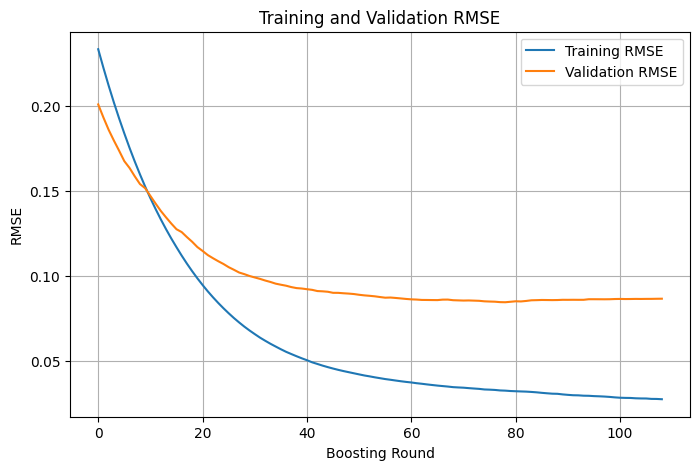

In [ ]:
results = model.evals_result()

plt.figure(figsize=(8,5))

plt.plot(
    results["validation_0"]["rmse"],
    label="Training RMSE"
)

plt.plot(
    results["validation_1"]["rmse"],
    label="Validation RMSE"
)

plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("Training and Validation RMSE")

plt.legend()

plt.grid(True)

plt.show()

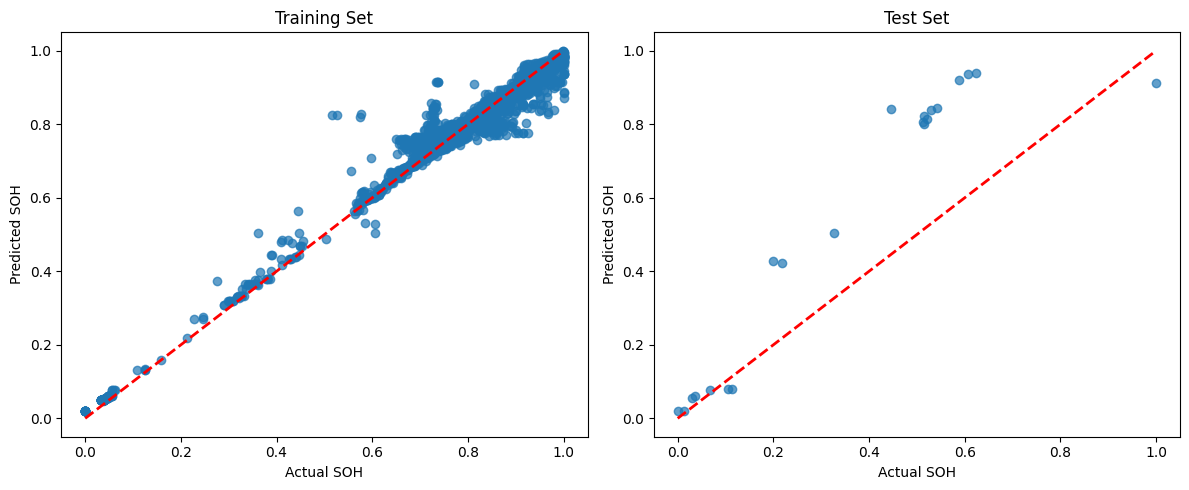

In [ ]:
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ===== Train =====
axes[0].scatter(Y_train, Y_train_pred, alpha=0.7)

axes[0].set_xlabel("Actual SOH")
axes[0].set_ylabel("Predicted SOH")
axes[0].set_title("Training Set")

x = np.linspace(
    min(Y_train.min(), Y_train_pred.min()),
    max(Y_train.max(), Y_train_pred.max()),
    100
)

axes[0].plot(x, x, "r--", linewidth=2)

# ===== Test =====
axes[1].scatter(Y_test, Y_test_pred, alpha=0.7)

axes[1].set_xlabel("Actual SOH")
axes[1].set_ylabel("Predicted SOH")
axes[1].set_title("Test Set")

x = np.linspace(
    min(Y_test.min(), Y_test_pred.min()),
    max(Y_test.max(), Y_test_pred.max()),
    100
)

axes[1].plot(x, x, "r--", linewidth=2)

plt.tight_layout()
plt.show()

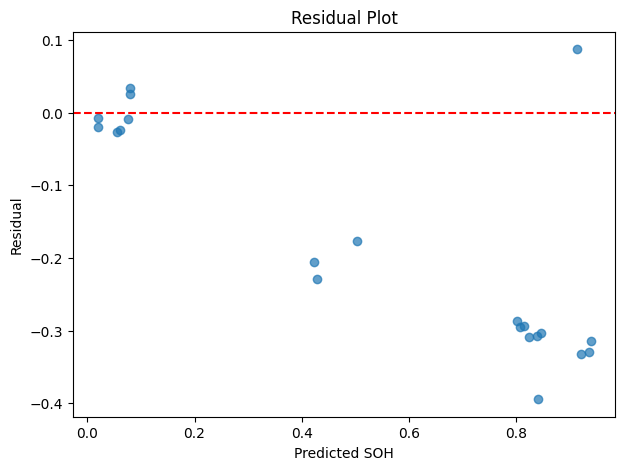

In [ ]:
residual = Y_test - Y_test_pred

plt.figure(figsize=(7,5))

plt.scatter(
    Y_test_pred,
    residual,
    alpha=0.7
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted SOH")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

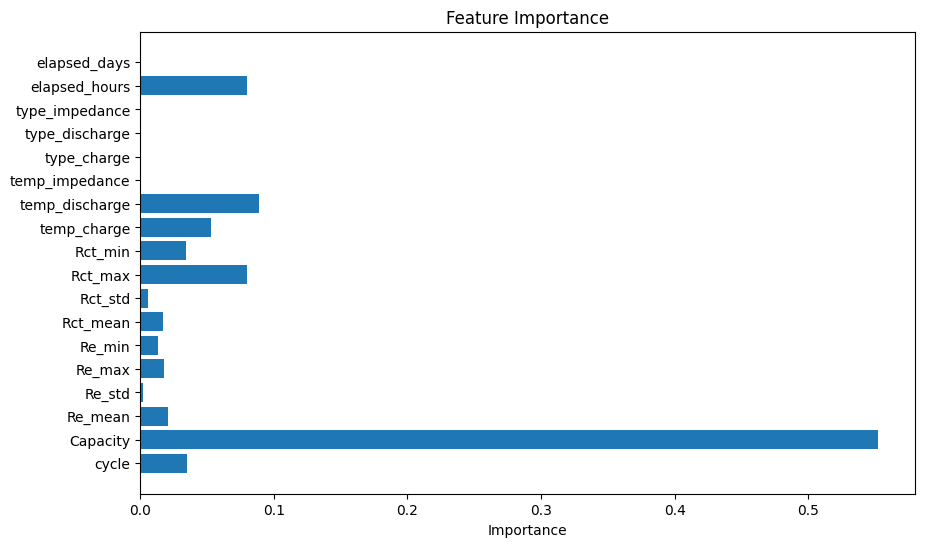

In [ ]:
importance = model.feature_importances_

plt.figure(figsize=(10,6))

plt.barh(
    X_train.columns,
    importance
)

plt.xlabel("Importance")

plt.title("Feature Importance")

plt.show()

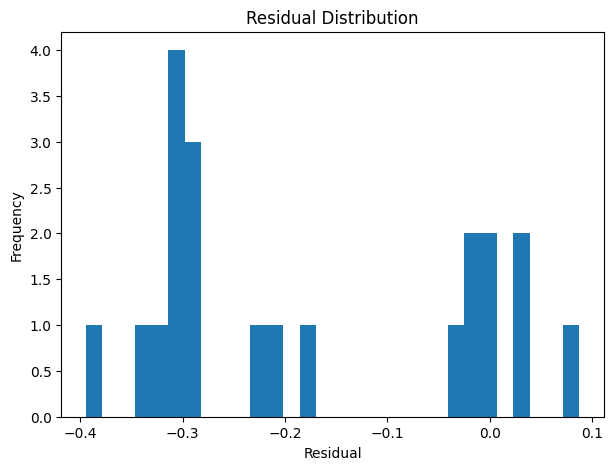

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(
    residual,
    bins=30
)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()

In [ ]:
rmse = np.sqrt(mean_squared_error(Y_test, Y_test_pred))
mae = mean_absolute_error(Y_test, Y_test_pred)
r2 = r2_score(Y_test, Y_test_pred)

print("RMSE =", rmse)
print("MAE  =", mae)
print("R²   =", r2)

RMSE = 0.233681479218087
MAE  = 0.1907462626695633
R²   = 0.22572964429855347


In [ ]:
print(f"Predicted SOH:", Y_test_pred[:10])
print(f"Actual SOH:", Y_test[:10])

Predicted SOH: [0.50280535 0.93842816 0.9358745  0.9204464  0.01932827 0.91260743
 0.80140615 0.8138038  0.8074065  0.82377124]
Actual SOH: 0    0.326930
1    0.624506
2    0.606646
3    0.587753
4    0.012332
5    1.000000
6    0.514754
7    0.520507
8    0.512396
9    0.515403
Name: SOH, dtype: float32
